In [ ]:
# Install packages
!pip install torch torch-geometric networkx -q

import torch
import pickle
import numpy as np
import pandas as pd
import networkx as nx
from torch_geometric.data import HeteroData
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✓ Packages installed")
print(f"PyTorch version: {torch.__version__}")
print(f"PyG available: {True}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.1 MB/s eta 0:00:00
✓ Packages installed
PyTorch version: 2.9.0+cpu
PyG available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Base path - SAME FOR ALL PHASES
base_path = '/content/drive/MyDrive/CSE 941'

# Phase number - CHANGE THIS for each phase (1, 2, 3, 4, 5, or 6)
phase_num = 3  # ← CHANGE THIS

output_dir = f'{base_path}/outputs/phase{phase_num}'
plots_dir = f'{output_dir}/plots'

import os
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

print(f"✓ Working in: {base_path}")
print(f"✓ Output directory: {output_dir}")

Mounted at /content/drive
✓ Working in: /content/drive/MyDrive/CSE 941
✓ Output directory: /content/drive/MyDrive/CSE 941/outputs/phase3


In [ ]:
# Load Phase 1 data
with open(f'{base_path}/outputs/phase1/processed_data.pkl', 'rb') as f:
    phase1_data = pickle.load(f)

reviews_df = phase1_data['reviews']
meta_df = phase1_data['metadata']

# Load Phase 2 embeddings
clip_embeddings = np.load(f'{base_path}/outputs/phase2/clip_embeddings.npy')
embedding_asins = np.load(f'{base_path}/outputs/phase2/embedding_asins.npy', allow_pickle=True)

with open(f'{base_path}/outputs/phase2/clip_embeddings_dict.pkl', 'rb') as f:
    embeddings_dict = pickle.load(f)

print("✓ Previous phase data loaded")
print(f"  Reviews: {len(reviews_df):,}")
print(f"  Users: {reviews_df['user_id'].nunique():,}")
print(f"  Items: {reviews_df['parent_asin'].nunique():,}")
print(f"  CLIP embeddings: {len(embeddings_dict):,}")

✓ Previous phase data loaded
  Reviews: 41,109
  Users: 10,000
  Items: 20,223
  CLIP embeddings: 20,219


In [ ]:
# Create ID mappings
unique_users = reviews_df['user_id'].unique()
unique_items = reviews_df['parent_asin'].unique()

user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
item_to_idx = {item: idx for idx, item in enumerate(unique_items)}

idx_to_user = {idx: user for user, idx in user_to_idx.items()}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

print("✓ ID mappings created")
print(f"  Users: {len(user_to_idx):,}")
print(f"  Items: {len(item_to_idx):,}")

# Save mappings
mappings = {
    'user_to_idx': user_to_idx,
    'item_to_idx': item_to_idx,
    'idx_to_user': idx_to_user,
    'idx_to_item': idx_to_item
}

with open(f'{output_dir}/id_mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)

print(f"✓ Mappings saved to {output_dir}/id_mappings.pkl")

✓ ID mappings created
  Users: 10,000
  Items: 20,223
✓ Mappings saved to /content/drive/MyDrive/CSE 941/outputs/phase3/id_mappings.pkl


In [ ]:
print("Building user-item interaction edges...")

# Create edge list
user_indices = []
item_indices = []
ratings = []

for _, row in tqdm(reviews_df.iterrows(), total=len(reviews_df), desc="Processing reviews"):
    user_id = row['user_id']
    item_id = row['parent_asin']
    rating = row['rating']

    if user_id in user_to_idx and item_id in item_to_idx:
        user_indices.append(user_to_idx[user_id])
        item_indices.append(item_to_idx[item_id])
        ratings.append(rating)

# Convert to tensors
user_item_edge_index = torch.tensor([user_indices, item_indices], dtype=torch.long)
user_item_edge_attr = torch.tensor(ratings, dtype=torch.float)

print("✓ User-item edges created")
print(f"  Total edges: {user_item_edge_index.shape[1]:,}")
print(f"  Edge index shape: {user_item_edge_index.shape}")

Building user-item interaction edges...


Processing reviews: 100%|██████████| 41109/41109 [00:02<00:00, 18653.33it/s]

✓ User-item edges created
  Total edges: 41,109
  Edge index shape: torch.Size([2, 41109])


In [ ]:
print("Building item-item similarity edges (OPTIMIZED)...")

# Get items with embeddings
items_with_emb = [item for item in unique_items if item in embeddings_dict]
print(f"Items with embeddings: {len(items_with_emb):,}")

# Create embedding matrix for vectorized computation
item_list = []
embedding_list = []

for item in items_with_emb:
    if item in item_to_idx:
        item_list.append(item)
        embedding_list.append(embeddings_dict[item])

embedding_matrix = np.array(embedding_list)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

# Compute ALL pairwise similarities at once (FAST)
print("Computing similarity matrix...")
similarity_matrix = cosine_similarity(embedding_matrix)

# Build edges from similarity matrix
print("Building edges from similarities...")
k_neighbors = 50
threshold = 0.5

item_item_edges = []
item_item_weights = []

for i in tqdm(range(len(item_list)), desc="Processing items"):
    target_item = item_list[i]
    target_idx = item_to_idx[target_item]

    # Get similarities for this item
    sims = similarity_matrix[i]

    # Get top-K (excluding self)
    top_k_indices = np.argsort(sims)[::-1][1:k_neighbors+1]

    for j in top_k_indices:
        sim_score = sims[j]
        if sim_score > threshold:
            neighbor_item = item_list[j]
            neighbor_idx = item_to_idx[neighbor_item]

            item_item_edges.append([target_idx, neighbor_idx])
            item_item_weights.append(sim_score)

# Convert to tensors
if len(item_item_edges) > 0:
    item_item_edge_index = torch.tensor(item_item_edges, dtype=torch.long).t()
    item_item_edge_attr = torch.tensor(item_item_weights, dtype=torch.float)
else:
    item_item_edge_index = torch.tensor([[], []], dtype=torch.long)
    item_item_edge_attr = torch.tensor([], dtype=torch.float)

print("✓ Item-item edges created")
print(f"  Total edges: {item_item_edge_index.shape[1]:,}")
print(f"  Avg similarity: {item_item_edge_attr.mean():.3f}" if len(item_item_edge_attr) > 0 else "")

Building item-item similarity edges (OPTIMIZED)...
Items with embeddings: 20,219
Embedding matrix shape: (20219, 512)
Computing similarity matrix...
Building edges from similarities...


Processing items: 100%|██████████| 20219/20219 [00:25<00:00, 799.26it/s]


✓ Item-item edges created
  Total edges: 1,010,430
  Avg similarity: 0.804


In [ ]:
print("Creating PyTorch Geometric heterogeneous graph...")

# Initialize HeteroData
data = HeteroData()

# Add node features (placeholder, will be learned)
data['user'].x = torch.eye(len(user_to_idx))  # One-hot initially
data['item'].x = torch.eye(len(item_to_idx))  # One-hot initially

# Add user-item edges
data['user', 'rates', 'item'].edge_index = user_item_edge_index
data['user', 'rates', 'item'].edge_attr = user_item_edge_attr.unsqueeze(1)

# Add reverse edges (item -> user)
data['item', 'rated_by', 'user'].edge_index = user_item_edge_index.flip([0])
data['item', 'rated_by', 'user'].edge_attr = user_item_edge_attr.unsqueeze(1)

# Add item-item edges
if item_item_edge_index.shape[1] > 0:
    data['item', 'similar_to', 'item'].edge_index = item_item_edge_index
    data['item', 'similar_to', 'item'].edge_attr = item_item_edge_attr.unsqueeze(1)

print("✓ HeteroData object created")
print(f"\n{data}")

Creating PyTorch Geometric heterogeneous graph...
✓ HeteroData object created

HeteroData(
  user={ x=[10000, 10000] },
  item={ x=[20223, 20223] },
  (user, rates, item)={
    edge_index=[2, 41109],
    edge_attr=[41109, 1],
  },
  (item, rated_by, user)={
    edge_index=[2, 41109],
    edge_attr=[41109, 1],
  },
  (item, similar_to, item)={
    edge_index=[2, 1010430],
    edge_attr=[1010430, 1],
  }
)


In [ ]:
# Compute graph statistics
n_users = len(user_to_idx)
n_items = len(item_to_idx)
n_nodes = n_users + n_items

n_user_item_edges = user_item_edge_index.shape[1]
n_item_item_edges = item_item_edge_index.shape[1] if item_item_edge_index.shape[1] > 0 else 0
n_edges = n_user_item_edges + n_item_item_edges * 2  # Bidirectional

density = n_edges / (n_nodes * (n_nodes - 1))
avg_degree = n_edges / n_nodes

stats = {
    'nodes': {
        'users': n_users,
        'items': n_items,
        'total': n_nodes
    },
    'edges': {
        'user_item': n_user_item_edges,
        'item_item': n_item_item_edges,
        'total': n_edges
    },
    'metrics': {
        'density': density,
        'avg_degree': avg_degree
    }
}

print("="*60)
print("GRAPH STATISTICS")
print("="*60)
print(f"\nNodes:")
print(f"  Users: {n_users:,}")
print(f"  Items: {n_items:,}")
print(f"  Total: {n_nodes:,}")

print(f"\nEdges:")
print(f"  User-Item: {n_user_item_edges:,}")
print(f"  Item-Item (similar_to): {n_item_item_edges:,}")
print(f"  Total: {n_edges:,}")

print(f"\nMetrics:")
print(f"  Density: {density:.6f}")
print(f"  Avg Degree: {avg_degree:.2f}")
print("="*60)

GRAPH STATISTICS

Nodes:
  Users: 10,000
  Items: 20,223
  Total: 30,223

Edges:
  User-Item: 41,109
  Item-Item (similar_to): 1,010,430
  Total: 2,061,969

Metrics:
  Density: 0.002257
  Avg Degree: 68.23


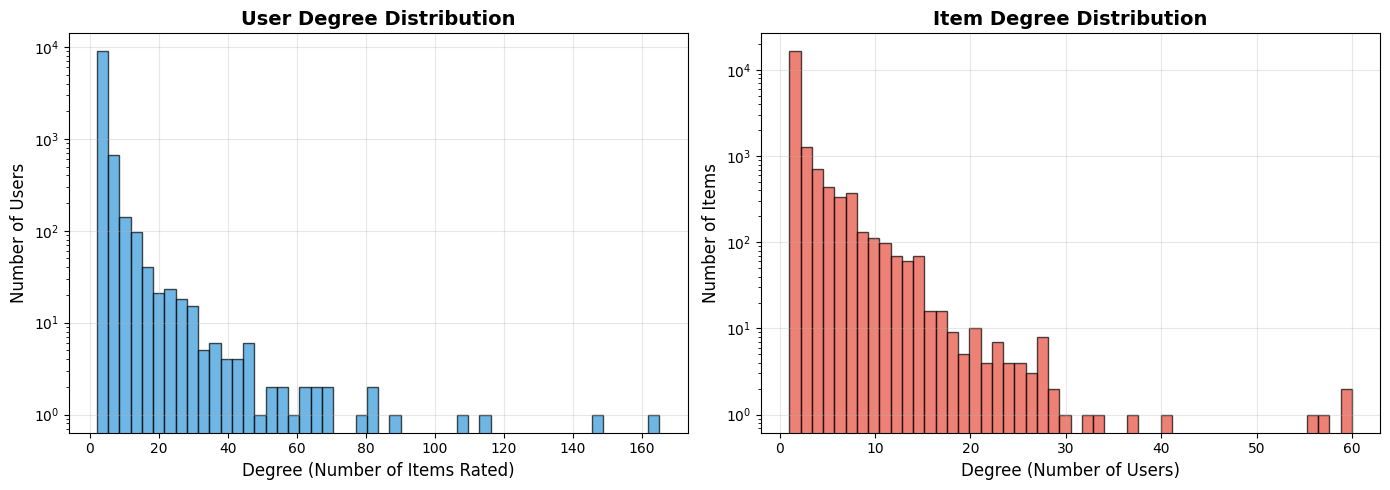

✓ Plot 1 saved
Avg user degree: 4.11
Avg item degree: 2.03


In [ ]:
# Compute degree distributions
user_degrees = torch.bincount(user_item_edge_index[0]).numpy()
item_degrees_from_users = torch.bincount(user_item_edge_index[1]).numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# User degree distribution
ax[0].hist(user_degrees, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Degree (Number of Items Rated)', fontsize=12)
ax[0].set_ylabel('Number of Users', fontsize=12)
ax[0].set_title('User Degree Distribution', fontsize=14, fontweight='bold')
ax[0].set_yscale('log')
ax[0].grid(alpha=0.3)

# Item degree distribution
ax[1].hist(item_degrees_from_users, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
ax[1].set_xlabel('Degree (Number of Users)', fontsize=12)
ax[1].set_ylabel('Number of Items', fontsize=12)
ax[1].set_title('Item Degree Distribution', fontsize=14, fontweight='bold')
ax[1].set_yscale('log')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/01_degree_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 1 saved")
print(f"Avg user degree: {user_degrees.mean():.2f}")
print(f"Avg item degree: {item_degrees_from_users.mean():.2f}")

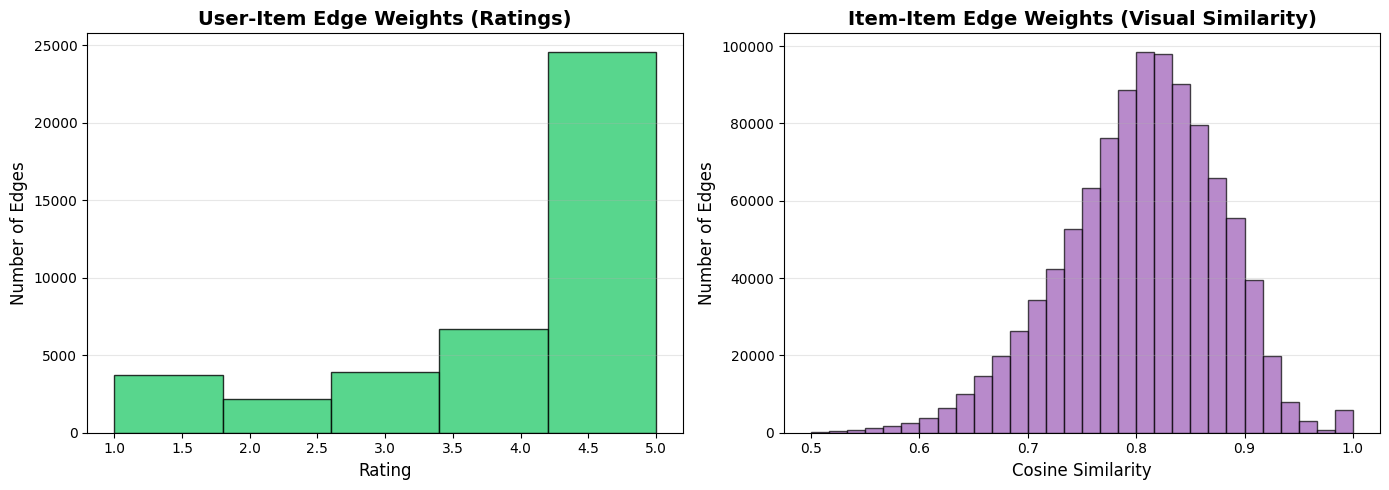

✓ Plot 2 saved


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# User-item rating distribution
ax[0].hist(user_item_edge_attr.numpy(), bins=5, color='#2ecc71', edgecolor='black', alpha=0.8)
ax[0].set_xlabel('Rating', fontsize=12)
ax[0].set_ylabel('Number of Edges', fontsize=12)
ax[0].set_title('User-Item Edge Weights (Ratings)', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

# Item-item similarity distribution
if item_item_edge_attr.shape[0] > 0:
    ax[1].hist(item_item_edge_attr.numpy(), bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
    ax[1].set_xlabel('Cosine Similarity', fontsize=12)
    ax[1].set_ylabel('Number of Edges', fontsize=12)
    ax[1].set_title('Item-Item Edge Weights (Visual Similarity)', fontsize=14, fontweight='bold')
    ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/02_edge_weights.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 2 saved")

In [ ]:
print("Saving graph data...")

# Save HeteroData object
torch.save(data, f'{output_dir}/hetero_graph.pt')

# Save statistics
import json
with open(f'{output_dir}/graph_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

# Save edge indices separately for convenience
torch.save({
    'user_item_edge_index': user_item_edge_index,
    'user_item_edge_attr': user_item_edge_attr,
    'item_item_edge_index': item_item_edge_index,
    'item_item_edge_attr': item_item_edge_attr
}, f'{output_dir}/edge_indices.pt')

print("✓ Graph data saved")
print(f"  HeteroData: {output_dir}/hetero_graph.pt")
print(f"  Statistics: {output_dir}/graph_stats.json")
print(f"  Edge indices: {output_dir}/edge_indices.pt")
print(f"  Total size: {(os.path.getsize(f'{output_dir}/hetero_graph.pt') / 1024**2):.2f} MB")

Saving graph data...
✓ Graph data saved
  HeteroData: /content/drive/MyDrive/CSE 941/outputs/phase3/hetero_graph.pt
  Statistics: /content/drive/MyDrive/CSE 941/outputs/phase3/graph_stats.json
  Edge indices: /content/drive/MyDrive/CSE 941/outputs/phase3/edge_indices.pt
  Total size: 1962.25 MB


In [ ]:
from datetime import datetime

print("\n" + "="*70)
print("PHASE 3 COMPLETE - FINAL REPORT")
print("="*70)
print(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

print("\n🕸️  GRAPH CONSTRUCTION STATISTICS:")
print(f"  Graph type: Heterogeneous (User-Item + Item-Item)")
print(f"  Framework: PyTorch Geometric")

print("\n📊 NODES:")
for key, val in stats['nodes'].items():
    print(f"  {key.capitalize()}: {val:,}")

print("\n🔗 EDGES:")
for key, val in stats['edges'].items():
    print(f"  {key.replace('_', '-').title()}: {val:,}")

print("\n📈 METRICS:")
for key, val in stats['metrics'].items():
    if isinstance(val, float):
        print(f"  {key.replace('_', ' ').title()}: {val:.6f}")
    else:
        print(f"  {key.replace('_', ' ').title()}: {val}")

print("\n💾 SAVED ARTIFACTS:")
print(f"  ✓ HeteroData object: {output_dir}/hetero_graph.pt")
print(f"  ✓ ID mappings: {output_dir}/id_mappings.pkl")
print(f"  ✓ Graph statistics: {output_dir}/graph_stats.json")
print(f"  ✓ Edge indices: {output_dir}/edge_indices.pt")

print("\n📂 OUTPUT LOCATION:")
print(f"  {output_dir}")

print("\n✅ READY FOR PHASE 4: GNN Training")
print("="*70)


PHASE 3 COMPLETE - FINAL REPORT
Completion Time: 2026-01-23 14:27:50

🕸️  GRAPH CONSTRUCTION STATISTICS:
  Graph type: Heterogeneous (User-Item + Item-Item)
  Framework: PyTorch Geometric

📊 NODES:
  Users: 10,000
  Items: 20,223
  Total: 30,223

🔗 EDGES:
  User-Item: 41,109
  Item-Item: 1,010,430
  Total: 2,061,969

📈 METRICS:
  Density: 0.002257
  Avg Degree: 68.225160

💾 SAVED ARTIFACTS:
  ✓ HeteroData object: /content/drive/MyDrive/CSE 941/outputs/phase3/hetero_graph.pt
  ✓ ID mappings: /content/drive/MyDrive/CSE 941/outputs/phase3/id_mappings.pkl
  ✓ Graph statistics: /content/drive/MyDrive/CSE 941/outputs/phase3/graph_stats.json
  ✓ Edge indices: /content/drive/MyDrive/CSE 941/outputs/phase3/edge_indices.pt

📂 OUTPUT LOCATION:
  /content/drive/MyDrive/CSE 941/outputs/phase3

✅ READY FOR PHASE 4: GNN Training
